# DSC 540 - Data Preparation #
## Week 11 Term Project: Milestone 5 ##
## Manoj K Kola ##

### Merging the Data and Storing in a Database/Visualizing Data

#### Import Required Libraries & Database Connection Setup

In this step, the required Python libraries are imported to work with the database and perform data analysis. The `sqlite3` library is used to connect to the SQLite database file, `pandas` is used to handle data in DataFrame format, and `matplotlib.pyplot` is used to create visualizations later in the project.

A connection to the SQLite database file named **manoj_project.db**is then created. After establishing the connection, a **cursor object** is created. The cursor allows SQL queries to be executed on the database.

A **try-except block** is used to handle potential errors during the connection process. If the connection is successful, a confirmation message is printed. If an error occurs, the exception message is displayed to help identify the issue.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Try to connect to the petsdb database
try:
    # Create a connection to the database file
    conn = sqlite3.connect('manoj_project.db')
    
    # Create a cursor object to execute SQL queries
    cursor = conn.cursor()
    
    # Print a success message if the connection works
    print("Database connection successful!\n")

# If any error occurs while connecting
except Exception as e:
    # Print the error message
    print("Error connecting to database:\n", e)


Database connection successful!



#### Creating the Final Combined Airport Dataset

In this step, a new table called **final_airport_data** is created by combining information from three different tables: **all_airports** (Dataset from the Wiki), **city_weather** (Dataset from the Weather API), and **city_population** (Dataset from the Kaggle csv file). 

First, the code removes the table if it already exists to avoid duplication errors when running the notebook multiple times. Then, a new table is created using a **LEFT JOIN** to merge the datasets based on the common fields **City** and **State**. This ensures that all airport records are kept, even if weather or population data is missing for some cities.

The resulting table contains airport details, along with corresponding **weather information and population data**, making it easier to perform further analysis in a single unified dataset. Finally, the changes are saved to the database using a commit operation.

In [2]:
# Drop the table if it already exists
cursor.execute("DROP TABLE IF EXISTS final_airport_data")

# Create the final table joining all_airports, city_weather, and city_population
cursor.execute("""
CREATE TABLE final_airport_data AS
SELECT 
    a.*,
    w.*,
    p.*
FROM all_airports a
LEFT JOIN city_weather w
    ON a.City = w.City AND a.State = w.State
LEFT JOIN city_population p
    ON a.City = p.City AND a.State = p.State
""")

# Commit the changes
conn.commit()

#### Verify Tables in the SQLite Database

After creating the final dataset, confirm that the tables were successfully created in the SQLite database. The following code queries the database system table (`sqlite_master`) to retrieve the names of all tables currently stored in the database.

This helps verify that the expected tables exist and ensures that the database structure is correct before continuing with further analysis.

This query returns a list of all tables in the connected database.

In [3]:
# Check tables in the database after creating the final dataset
query = "SELECT name FROM sqlite_master WHERE type='table';"
pd.read_sql(query, conn)

,name
0,city_population
1,large_hub_airports
2,medium_hub_airports
3,busiest_airports
4,all_airports
5,city_weather
6,final_airport_data


#### Load Data from SQLite Database

In this step, the data from the SQLite database is loaded into Pandas DataFrames for analysis.  
Three tables are read from the database:

- **all_airports** – Contains airport traffic and airport details.
- **city_weather** – Contains weather information for the cities where airports are located.
- **city_population** – Contains population information for those cities.

Each table is loaded into a separate Pandas DataFrame using `pd.read_sql()`.  
After loading the data, the total number of records in each DataFrame is printed to confirm that the data was successfully retrieved from the database.

In [4]:
# Read all records from the 'all_airports' table into a pandas DataFrame
airport_df = pd.read_sql("SELECT * FROM all_airports", conn)

# Print the total number of records in the airport DataFrame
print("\nTotal Records in airport_df:", len(airport_df))


# Read all records from the 'city_weather' table into a pandas DataFrame
weather_df = pd.read_sql("SELECT * FROM city_weather", conn)

# Print the total number of records in the weather DataFrame
print("\nTotal Records in weather_df:", len(weather_df))


# Read all records from the 'city_population' table into a pandas DataFrame
population_df = pd.read_sql("SELECT * FROM city_population", conn)

# Print the total number of records in the population DataFrame
print("\nTotal Records in population_df:", len(population_df))


Total Records in airport_df: 93

Total Records in weather_df: 59

Total Records in population_df: 28450


#### Load Final Airport Data from SQLite

The following code reads all records from the **`final_airport_data`** table in the SQLite database and loads them into a Pandas DataFrame called **`final_df`**. After loading the data, it prints the DataFrame's total number of rows to confirm how many records were retrieved from the database.

This step helps verify that the data has been successfully loaded and allows us to understand the dataset size before performing further analysis.


In [5]:
# Read all data from the final_airport_data table into a pandas DataFrame
final_df = pd.read_sql("SELECT * FROM final_airport_data", conn)

# Print the total number of records (rows) in the DataFrame
print("\nTotal Records in final_df:", len(final_df))


Total Records in final_df: 94


#### Displaying Column Names of the DataFrame

The following code is used to display the names of all columns present in the **`final_df`** DataFrame. This helps verify the dataset's structure and ensures the expected columns are available for further analysis or processing.

By checking the column names, we can confirm that the data was loaded and combined correctly before performing additional operations such as filtering, aggregation, or visualization.


In [26]:
# Display the column names of the DataFrame
final_df.columns

Index(['Rank', 'Airport', 'IATA_Code', 'City', 'Metro_Area', 'State',
       'Passengers_2024', 'Passengers_2023', 'Passengers_2022',
       'Passengers_2021', 'Passengers_2020', 'Passengers_2019',
       'Passengers_2018', 'Passengers_2017', 'Passengers_2016',
       'Passengers_2015', 'Pct_Change_24_23', 'Airport_Type', 'City:1',
       'State:1', 'Country', 'Dt', 'Id', 'Name', 'Coord.Lon', 'Coord.Lat',
       'Temperature_F', 'Feels_Like_F', 'Temp_Min_F', 'Temp_Max_F', 'Pressure',
       'Humidity_Pct', 'Sea_Level', 'Grnd_Level', 'Wind_Speed_Mph',
       'Wind_Direction_Deg', 'Clouds.All', 'Sys.Type', 'Sys.Id',
       'Country_Code', 'Sys.Sunrise', 'Sys.Sunset', 'Gust', 'Snow.1H',
       'Rain.1H', 'Weather_Id', 'Weather_Main', 'Weather_Description',
       'Weather_Icon', 'Timestamp', 'Sunrise', 'Sunset', 'Temp_Range_F',
       'Is_Daytime', 'INDEX', 'TABLE_ID', 'CITY:2', 'SUMMARY_LEVEL',
       'PLACE_FIPS', 'GEO_ID', 'STATE:2', 'STATE_FIPS', 'TOTAL_POPULATION'],
      dtype='obje

#### Visualization 1 – Top 10 Airports by Passenger Traffic (2024)

This code sorts the dataset based on the number of passengers in **2024** and selects the **top 10 airports with the highest passenger traffic**.  
A **bar chart** is then created using Matplotlib to visually compare the passenger counts of these airports.

- The dataframe is sorted in **descending order** using the `Passengers_2024` column.
- The **top 10 airports** are selected using `.head(10)`.
- A **bar chart** is created where:
  - The **x-axis** represents the airport names.
  - The **y-axis** represents the number of passengers in 2024.
- Airport labels are **rotated for better readability**.
- The chart includes a **title and axis labels** to clearly describe the visualization.

This visualization helps identify the **busiest airports based on passenger traffic in 2024**, making it easier to analyze airport activity and compare passenger volumes across major airports.

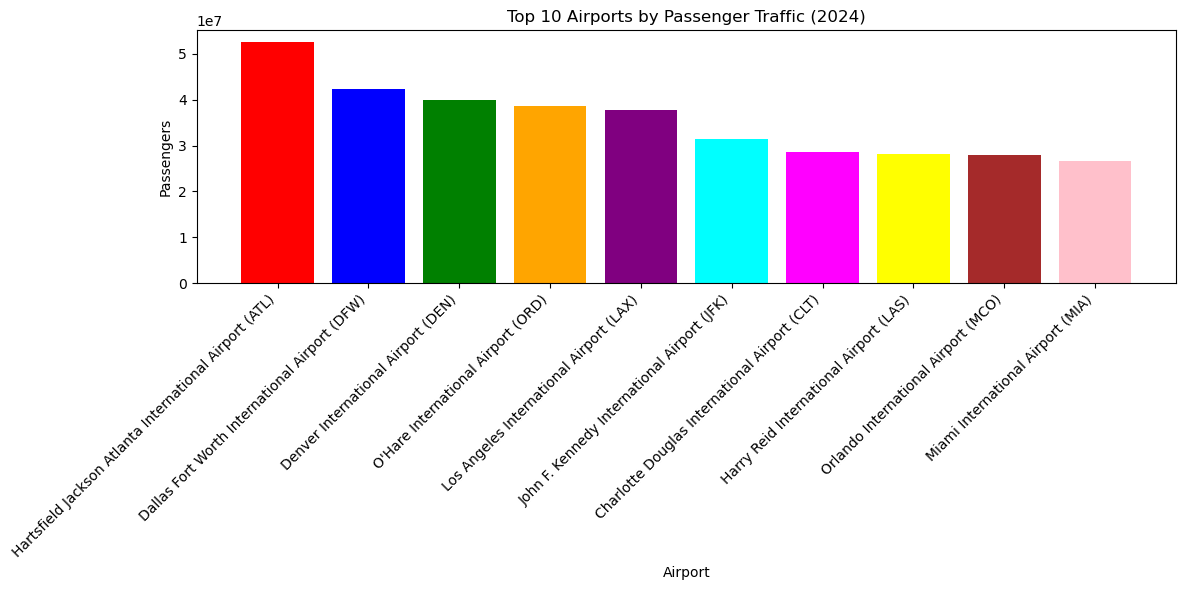

In [19]:
# Select top 10 airports by Passengers_2024 with distinct airport names
top_airports = (
    final_df.drop_duplicates(subset="Airport")  # remove duplicate airport names
            .sort_values("Passengers_2024", ascending=False)
            .head(10)
)

# Create a new column for unique labels by combining Airport name and IATA code
top_airports["Airport_Label"] = top_airports["Airport"] + " (" + top_airports["IATA_Code"] + ")"

# Create a new figure for the bar chart
plt.figure(figsize=(12,6))

# Define a list of 10 colors, one for each airport
colors = [
    "red", "blue", "green", "orange", "purple",
    "cyan", "magenta", "yellow", "brown", "pink"
]

# Create a bar chart with different colors for each airport
plt.bar(top_airports["Airport_Label"], top_airports["Passengers_2024"], color=colors)

# Rotate the airport names on the x-axis for better readability
plt.xticks(rotation=45, ha='right')

# Add a title to the chart
plt.title("Top 10 Airports by Passenger Traffic (2024)")

# Label the x-axis
plt.xlabel("Airport")

# Label the y-axis
plt.ylabel("Passengers")

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the chart
plt.show()

#### Visualization 2 – Airport Type Distribution

The following code analyzes the distribution of airport categories in the dataset and visualizes the results using a bar chart.

First, the `value_counts()` function is used to count the number of airports in each `Airport_Type` category in the `final_df` DataFrame. This helps summarize the number of airports by type.

Next, a new plot figure is created using Matplotlib. The airport type counts are then displayed as a **bar chart**, which makes it easy to compare the number of airports in each category visually.

The chart is improved by adding a **title** and labeling both the **x-axis** (Airport Type) and **y-axis** (Count). Finally, `plt.show()` is used to display the chart.

This visualization helps quickly understand how airports are distributed across different airport types in the dataset.

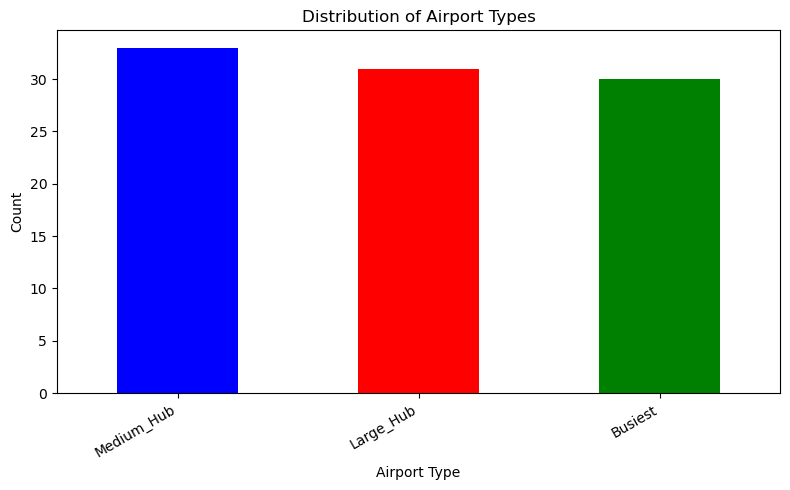

In [24]:
# Count the number of airports for each type
airport_type_counts = final_df["Airport_Type"].value_counts()

# Create a new figure for the plot
plt.figure(figsize=(8,5))

# Define colors for each airport type
# Adjust the colors as needed for your dataset
colors = {
    "Large_Hub": "red",
    "Medium_Hub": "blue",
    "Busiest": "green"
}

# Map the colors to the order of the bars
bar_colors = [colors[atype] for atype in airport_type_counts.index]

# Plot the counts as a bar chart with specified colors
airport_type_counts.plot(kind="bar", color=bar_colors)

# Add a title to the chart
plt.title("Distribution of Airport Types")

# Label the x-axis
plt.xlabel("Airport Type")

# Label the y-axis
plt.ylabel("Count")

# Rotate x-axis labels slightly for readability
plt.xticks(rotation=30, ha='right')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

#### Visualization 3 – Population vs Passenger Traffic

The following code creates a scatter plot to visualize the relationship between the **total population of a city** and the **number of airport passengers in 2024**.

- A new plot figure is created using Matplotlib.
- A scatter plot is generated using the `TOTAL_POPULATION` column for the x-axis and `Passengers_2024` for the y-axis.
- The chart helps analyze whether cities with larger populations tend to have higher airport passenger traffic.
- The plot also includes a title and labels for both axes to make the visualization easier to understand.

Finally, the plot is displayed using `plt.show()`.

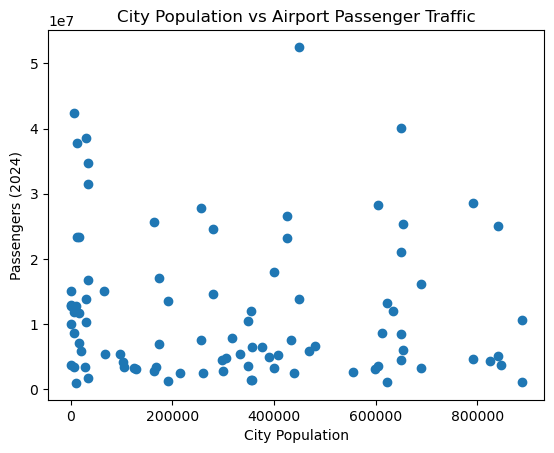

In [63]:
# Create a new figure for the plot
plt.figure()

# Create a scatter plot of city population vs. airport passengers in 2024
plt.scatter(final_df["TOTAL_POPULATION"], final_df["Passengers_2024"])

# Add a title to the plot
plt.title("City Population vs Airport Passenger Traffic")

# Label the x-axis
plt.xlabel("City Population")

# Label the y-axis
plt.ylabel("Passengers (2024)")

# Display the plot
plt.show()

#### Visualization 4 – Scatter Plot: Temperature vs Passenger Traffic

The following code creates a scatter plot to visualize the relationship between the **temperature** of a city and the **number of airport passengers in 2024**.

- A new plot figure is created using Matplotlib.
- A scatter plot is generated using the `Temperature_F` column for the x-axis and `Passengers_2024` for the y-axis.
- The chart helps analyze whether cities with higher or lower temperatures tend to have more airport passenger traffic.
- The plot also includes a title and labels for both axes to make the visualization easier to understand.

Finally, the plot is displayed using `plt.show()`.

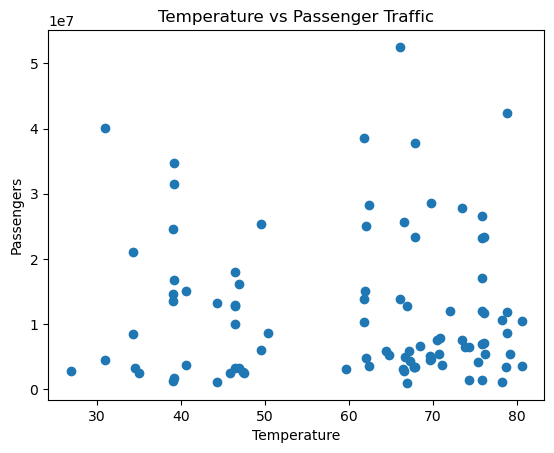

In [27]:
# Create a new figure for the plot
plt.figure()

# Create a scatter plot with Temperature on X-axis and Passengers on Y-axis
plt.scatter(final_df["Temperature_F"], final_df["Passengers_2024"])

# Add a title to the plot
plt.title("Temperature vs Passenger Traffic")

# Label the X-axis
plt.xlabel("Temperature")

# Label the Y-axis
plt.ylabel("Passengers")

# Display the plot
plt.show()

#### Visualization 5 – Line Chart: Passenger Trend Over Years

The following code creates a line chart to visualize the **trend of total airport passengers from 2018 to 2024**.

- A list of columns representing passenger counts for each year is defined.
- The total passengers for each year are calculated by summing the values across all cities.
- A new plot figure is created using Matplotlib.
- The passenger trend is plotted as a **line chart with markers** to highlight each year's data point.
- The chart includes a title and labels for both axes to make the trend easy to interpret.

Finally, the plot is displayed using `plt.show()`.

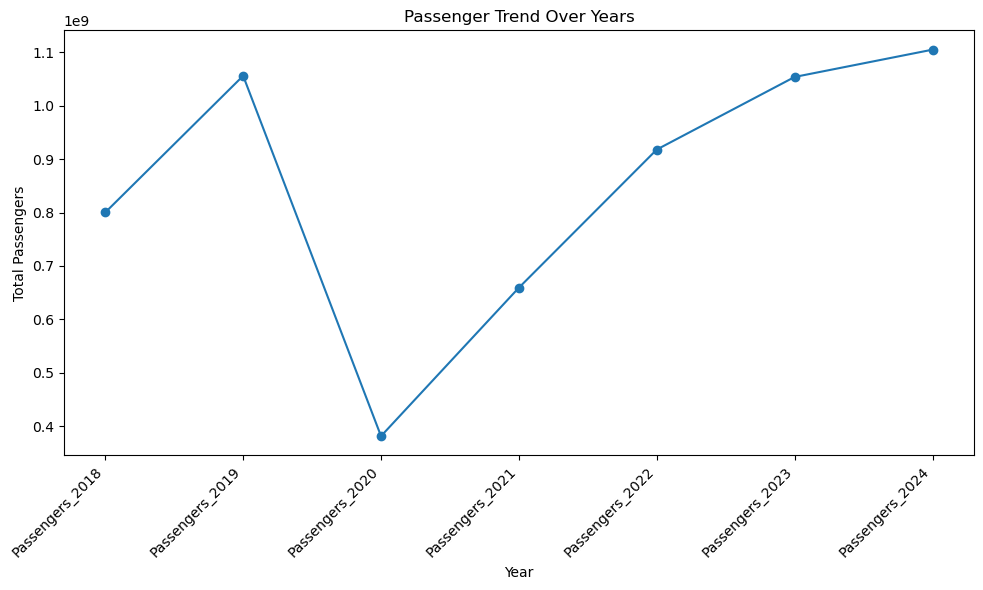

In [28]:
# List of columns representing passenger counts for each year
years = ["Passengers_2018", "Passengers_2019", "Passengers_2020", 
         "Passengers_2021", "Passengers_2022", "Passengers_2023", "Passengers_2024"]

# Calculate the total passengers for each year
trend = final_df[years].sum()

# Create a new figure for the plot
plt.figure(figsize=(10,6))  # Optional: make figure larger for readability

# Plot the passenger trend as a line chart with markers for each year
trend.plot(kind="line", marker="o")

# Set the title of the plot
plt.title("Passenger Trend Over Years")

# Label the x-axis
plt.xlabel("Year")

# Label the y-axis
plt.ylabel("Total Passengers")

# Rotate x-axis labels for clarity
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

#### Visualization 6 — Scatter Plot: Airport Passenger Traffic (2019) vs Airport Passenger Traffic (2024)

The following code creates a scatter plot to visualize the relationship between the **number of airport passengers in 2019** and the **number of airport passengers in 2024**.

- A new plot figure is created using Matplotlib.
- A scatter plot is generated using the `Passengers_2019` column for the x-axis and `Passengers_2024` for the y-axis.
- The plot also includes a title and labels for both axes to make the visualization easier to understand.

Finally, the plot is displayed using `plt.show()`.

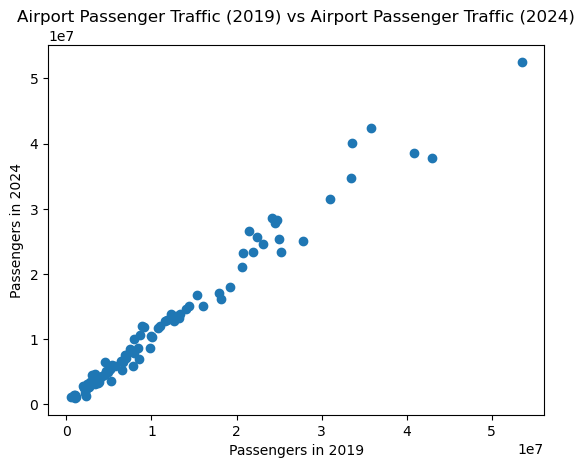

In [29]:
# Create a new figure for the plot
plt.figure()

# Create a scatter plot with 2019 passengers on the x-axis and the 2024 passengers on the y-axis
plt.scatter(final_df["Passengers_2019"], final_df["Passengers_2024"])

# Set the title of the plot
plt.title("Airport Passenger Traffic (2019) vs Airport Passenger Traffic (2024)")

# Label the x-axis
plt.xlabel("Passengers in 2019")

# Label the y-axis
plt.ylabel("Passengers in 2024")

# Display the plot
plt.show()

#### Visualization 7 — Bar Chart: Top 10 Airports by Passenger Growth (2022–2024)

The following code calculates the **passenger growth** for each airport between 2022 and 2024 and visualizes the **top 10 airports** with the highest growth.  

- A new column `Passenger_Growth` is added to `final_df` by subtracting `Passengers_2022` from `Passengers_2024`.
- The top 10 airports with the largest growth are selected by sorting the data in descending order.
- A bar chart is created to show the **airport codes** on the x-axis and their corresponding **passenger growth** on the y-axis.
- The chart includes a title and axis labels for clarity.
- Finally, the bar chart is displayed using `plt.show()`.

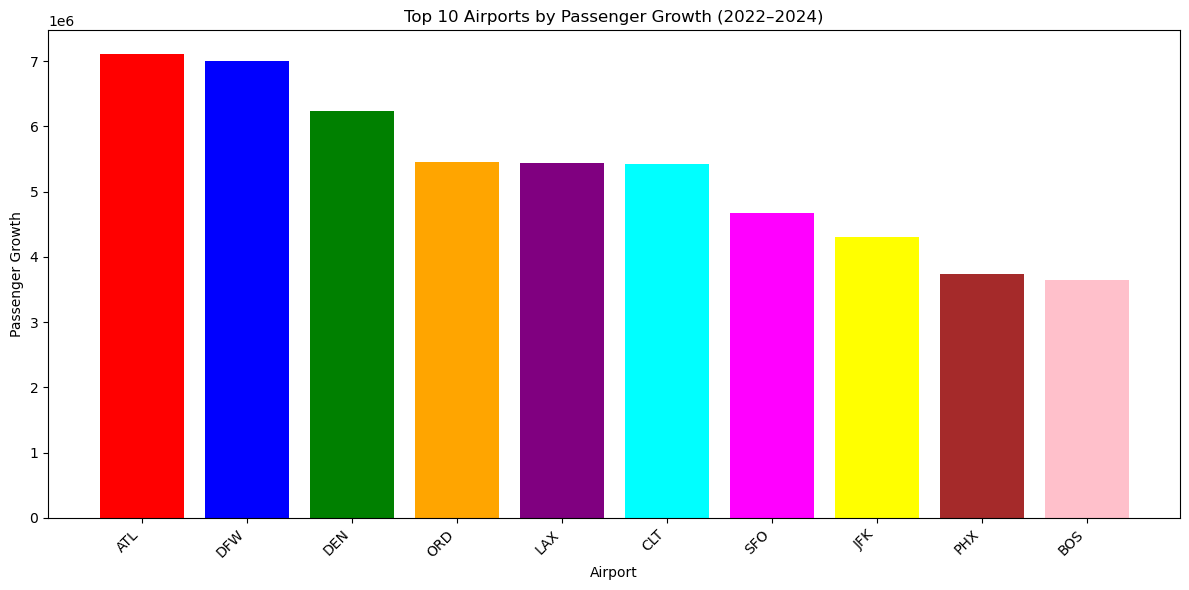

In [37]:
# Calculate the passenger growth between 2022 and 2024
final_df["Passenger_Growth"] = final_df["Passengers_2024"] - final_df["Passengers_2022"]

# Get the top 10 airports with the highest passenger growth
top_growth = (
    final_df.drop_duplicates(subset="Airport")  # remove duplicate airport names
            .sort_values("Passenger_Growth", ascending=False)
            .head(10)
)

# Create a new figure for the bar chart
plt.figure(figsize=(12,6))

# Define 10 distinct colors, one for each airport
colors = [
    "red", "blue", "green", "orange", "purple",
    "cyan", "magenta", "yellow", "brown", "pink"
]

# Plot the bar chart with unique labels and colors
plt.bar(top_growth["IATA_Code"], top_growth["Passenger_Growth"], color=colors)

# Rotate the x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Add a title and axis labels
plt.title("Top 10 Airports by Passenger Growth (2022–2024)")
plt.xlabel("Airport")
plt.ylabel("Passenger Growth")

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the chart
plt.show()

#### Visualization 8 — Bar Chart: Average City Population by Airport Type

The following code calculates and visualizes the **average number of passengers in 2024** for each **airport type**.

- First, the data is grouped by the `Airport_Type` column, and the mean of `Passengers_2024` is calculated.
- A new figure is created using Matplotlib.
- The average passengers for each airport type are displayed as a **bar chart**.
- The chart includes a title and labels for both axes to clearly indicate the airport type and average passenger traffic.
- This visualization helps compare airport traffic across different types of airports.

Finally, the bar chart is displayed using `plt.show()`.

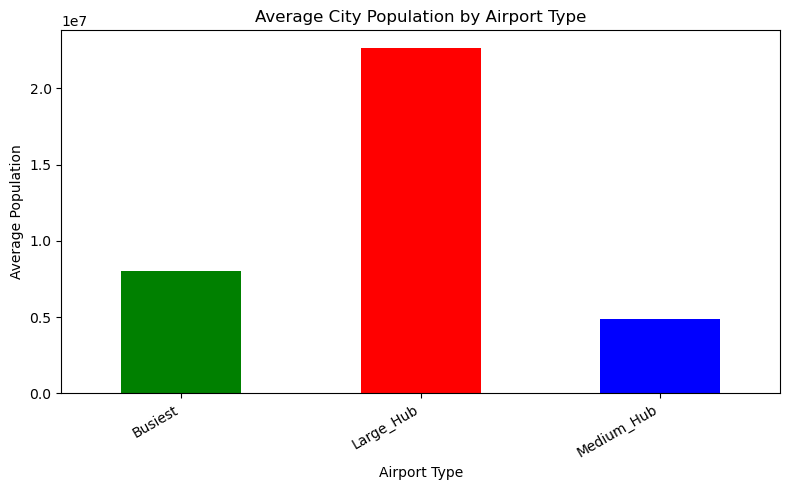

In [41]:
# Calculate the average number of passengers in 2024 for each airport type
avg_population = final_df.groupby("Airport_Type")["Passengers_2024"].mean()

# Create a new figure for the plot
plt.figure(figsize=(8,5))

# Define colors for each airport type (adjust according to your dataset)
colors = {
    "Large_Hub": "red",
    "Medium_Hub": "blue",
    "Busiest": "green"
}

# Map the colors to the order of the bars
bar_colors = [colors[atype] for atype in avg_population.index]

# Plot the average passengers as a bar chart with specified colors
avg_population.plot(kind="bar", color=bar_colors)

# Set the title of the chart
plt.title("Average City Population by Airport Type")

# Label the x-axis
plt.xlabel("Airport Type")

# Label the y-axis
plt.ylabel("Average Population")

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha='right')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

#### Visualization 9 — Scatter Plot: Weather Temperature vs Airport 

The following code creates a scatter plot to visualize the relationship between a city's **Weather temperature** and the **airport**.

- A new plot figure is created using Matplotlib.
- A scatter plot is generated using the `Temperature_F` column for the x-axis and `IATA_Code` for the y-axis.
- The chart helps analyze which cities' airports have higher or lower temperatures.
- The plot also includes a title and labels for both axes to make the visualization easier to interpret.

Finally, the plot is displayed using `plt.show()`.

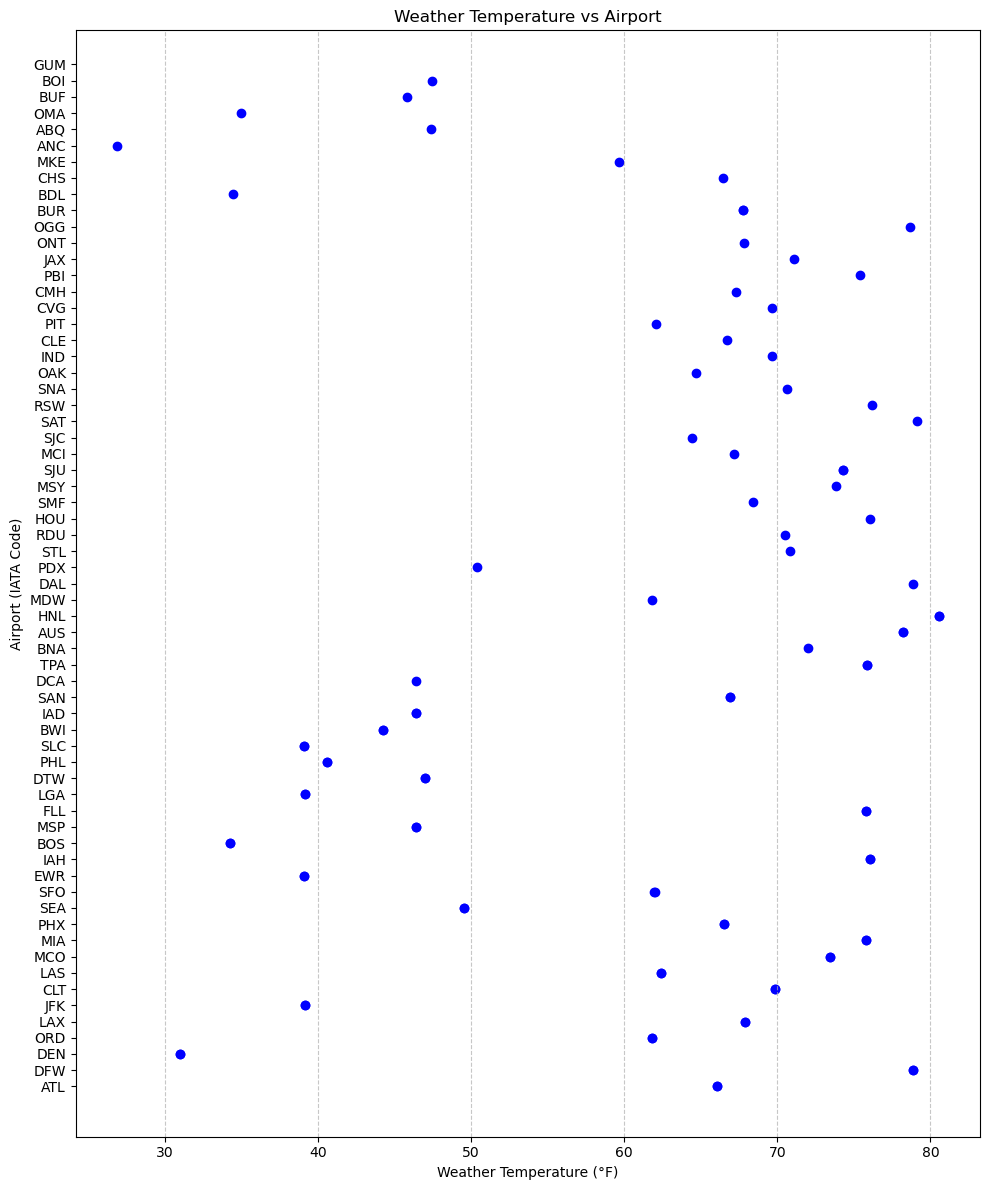

In [44]:
# Create a new figure with larger size
plt.figure(figsize=(10,12))

# Create a horizontal scatter plot: Passengers vs Airport
plt.scatter(final_df["Temperature_F"], final_df["IATA_Code"], color='blue')

# Add a title to the plot
plt.title("Weather Temperature vs Airport")

# Label the x-axis
plt.xlabel("Weather Temperature (°F)")

# Label the y-axis
plt.ylabel("Airport (IATA Code)")

# Rotate y-axis labels slightly for readability
plt.yticks(rotation=0)  # 0° keeps them horizontal, better for horizontal scatter

# Add gridlines for easier reading
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

#### Project Summary and Ethical Considerations

This project involved cleaning, transforming, storing, and analyzing airport data from three different datasets: airport traffic data (**all_airports**), weather data (**city_weather**), and population data (**city_population**). The datasets were first cleaned and standardized so that they could be joined using common fields such as **City** and **State**. After cleaning, each dataset was loaded into a **SQLite database** as individual tables. SQL joins were then used to merge these tables into a consolidated dataset called **final_airport_data**. This allowed information from multiple sources to be analyzed together.

Several transformations were performed on the data. Missing values were handled, column names were standardized, and a new column, **Airport_Type**, was created to categorize airports by passenger count. Additionally, the three datasets were merged using SQL joins to produce a single dataset suitable for visualization and analysis.

There are important ethical considerations when performing data cleansing and transformation. One risk is that modifying or filtering data may unintentionally introduce bias or misrepresent the original dataset. For example, if missing values are incorrectly replaced or assumptions are made about airport classifications, the resulting analysis may be misleading. Another concern involves data accuracy and credibility. The datasets used in this project were sourced from publicly available sources and were deemed credible. However, it is always important to verify the data's origin and ensure it complies with any applicable legal or regulatory guidelines.

During the cleaning process, assumptions were made about how to interpret missing or zero values. For instance, airports with zero passenger traffic in certain years were categorized as **"Busiest"** in the dataset. Such assumptions can introduce risk if they do not accurately represent real-world conditions. But this is due to data unavailability.

To mitigate ethical concerns, it is important to clearly document all transformations, assumptions, and data sources. Transparency ensures that others can understand how the dataset was prepared and evaluate whether the conclusions drawn from the data are valid. Ensuring data is obtained from reputable sources and maintaining proper documentation helps promote ethical data analysis practices.

### Final Dataset Output (Human Readable)

#### Display Airport Dataset

The following code displays the **entire Airport dataset** stored in the `airport_df` DataFrame.

- This allows you to **view all records** in the dataset.
- Useful for quickly checking the **structure, column names, and data values**.
- Helps in understanding the dataset before performing any **analysis or visualization**.

Simply running `airport_df` prints all rows and columns in the notebook output.

In [70]:
# Print the Airport dataset to display all the records
airport_df 

,Rank,Airport,IATA_Code,City,Metro_Area,State,Passengers_2024,Passengers_2023,Passengers_2022,Passengers_2021,Passengers_2020,Passengers_2019,Passengers_2018,Passengers_2017,Passengers_2016,Passengers_2015,Pct_Change_24_23,Airport_Type
0,1,Hartsfield Jackson Atlanta International Airport,ATL,Atlanta,Metro Atlanta,GA,52511402,50950068,45396001,36676010,20559866,53505795,51865797,50251964,50501858,49340732,3.06%,Large_Hub
1,2,Dallas Fort Worth International Airport,DFW,Dallas,Dallas–Fort Worth,TX,42351316,39246212,35345138,30005266,18593421,35778573,32821799,31816933,31283579,31589839,7.91%,Large_Hub
2,3,Denver International Airport,DEN,Denver,Greater Denver,CO,40012895,37863967,33773832,28645527,16243216,33592945,31362941,29809097,28267394,26280043,5.68%,Large_Hub
3,4,O'Hare International Airport,ORD,Chicago,Chicago,IL,38575693,35843104,33120474,26350976,14606034,40871223,39873927,38593028,37589899,36305668,7.62%,Large_Hub
4,5,Los Angeles International Airport,LAX,Los Angeles,Greater Los Angeles,CA,37760834,40956673,32326616,23663410,14055777,42939104,42624050,41232432,39636042,36351272,-7.8%,Large_Hub
5,6,John F. Kennedy International Airport,JFK,New York City,New York Metro,NY,31466102,30804355,27154885,15273342,8269819,31036655,30620769,29533154,29239151,27782369,2.15%,Large_Hub
6,7,Charlotte Douglas International Airport,CLT,Charlotte,Greater Charlotte,NC,28523822,25896224,23100300,20900875,12952869,24199688,22281949,22011251,21511880,21913166,10.15%,Large_Hub
7,8,Harry Reid International Airport,LAS,Las Vegas,Las Vegas Valley,NV,28244966,27896199,25480500,19160342,10584059,24728361,23795012,23364393,22833267,21857693,1.25%,Large_Hub
8,9,Orlando International Airport,MCO,Orlando,Greater Orlando,FL,27859783,28033205,24469733,19618838,10467728,24562271,23202480,21565448,20283541,18759938,-0.62%,Large_Hub
9,10,Miami International Airport,MIA,Miami,Miami Metro,FL,26588002,24717048,23949892,17500096,8786007,21421031,21021640,20709225,20875813,20986349,7.57%,Large_Hub


#### Display Weather Dataset

The following code displays the **entire Weather dataset** stored in the `weather_df` DataFrame.

- Printing the DataFrame allows us to **inspect all records** and check for missing or inconsistent data.
- This step is useful for **understanding the structure** of the dataset, including columns such as temperature, humidity, and weather conditions.
- Viewing the dataset helps in planning **data cleaning, transformation, and analysis** steps.

In [71]:
# Print the Weather dataset to display all the records
weather_df

,City,State,Country,Dt,Id,Name,Coord.Lon,Coord.Lat,Temperature_F,Feels_Like_F,Temp_Min_F,Temp_Max_F,Pressure,Humidity_Pct,Sea_Level,Grnd_Level,Wind_Speed_Mph,Wind_Direction_Deg,Clouds.All,Sys.Type,Sys.Id,Country_Code,Sys.Sunrise,Sys.Sunset,Gust,Snow.1H,Rain.1H,Weather_Id,Weather_Main,Weather_Description,Weather_Icon,Timestamp,Sunrise,Sunset,Temp_Range_F,Is_Daytime
0,Atlanta,GA,US,1772847912,4180439,Atlanta,-84.3880,33.7490,66.06,66.13,63.68,68.34,1023,80,1023,989,0.00,0,100,2.0,2101395.0,US,1772798398,1772840276,NaN,NaN,NaN,804,Clouds,Overcast Clouds,04n,2026-03-07 01:45:12,2026-03-06 11:59:58,2026-03-06 23:37:56,4.66,0
1,Dallas,TX,US,1772848070,4684904,Dallas,-96.7836,32.7668,78.84,78.84,76.32,80.74,1009,60,1009,991,16.11,170,75,2.0,2018848.0,US,1772801340,1772843283,23.02,NaN,NaN,803,Clouds,Broken Clouds,04n,2026-03-07 01:47:50,2026-03-06 12:49:00,2026-03-07 00:28:03,4.42,0
2,Denver,CO,US,1772848183,5419384,Denver,-104.9847,39.7392,30.96,25.00,29.84,32.68,1020,93,1020,836,5.99,62,97,2.0,2106186.0,US,1772803537,1772845022,13.00,0.65,NaN,601,Snow,Snow,13n,2026-03-07 01:49:43,2026-03-06 13:25:37,2026-03-07 00:57:02,2.84,0
3,Chicago,IL,US,1772848056,4887398,Chicago,-87.6500,41.8500,61.84,62.15,60.19,63.16,1011,94,1011,989,9.22,210,100,2.0,2075214.0,US,1772799460,1772840780,NaN,NaN,0.85,500,Rain,Light Rain,10n,2026-03-07 01:47:36,2026-03-06 12:17:40,2026-03-06 23:46:20,2.97,0
4,Los Angeles,CA,US,1772847969,5368361,Los Angeles,-118.2437,34.0522,67.86,65.98,65.01,72.16,1016,35,1016,996,10.36,200,0,2.0,2075946.0,US,1772806526,1772848397,19.57,NaN,NaN,800,Clear,Clear Sky,01d,2026-03-07 01:46:09,2026-03-06 14:15:26,2026-03-07 01:53:17,7.15,1
5,New York City,NY,US,1772848036,5128581,New York,-74.0060,40.7143,39.13,32.92,37.17,40.57,1031,82,1031,1029,9.22,40,100,1.0,4610.0,US,1772796146,1772837546,NaN,NaN,NaN,804,Clouds,Overcast Clouds,04n,2026-03-07 01:47:16,2026-03-06 11:22:26,2026-03-06 22:52:26,3.40,0
6,Charlotte,NC,US,1772847965,4460243,Charlotte,-80.8431,35.2271,69.82,69.93,65.57,71.69,1024,73,1024,999,1.01,162,99,2.0,2108613.0,US,1772797595,1772839378,5.99,NaN,NaN,804,Clouds,Overcast Clouds,04n,2026-03-07 01:46:05,2026-03-06 11:46:35,2026-03-06 23:22:58,6.12,0
7,Las Vegas,NV,US,1772847945,5506956,Las Vegas,-115.1372,36.1750,62.37,59.14,59.65,63.28,1015,18,1015,948,16.11,330,0,1.0,6171.0,US,1772805849,1772847583,24.16,NaN,NaN,800,Clear,Clear Sky,01n,2026-03-07 01:45:45,2026-03-06 14:04:09,2026-03-07 01:39:43,3.63,0
8,Orlando,FL,US,1772848055,4167147,Orlando,-81.3792,28.5383,73.42,74.55,71.89,74.10,1023,87,1023,1020,12.66,100,0,2.0,2084244.0,US,1772797522,1772839709,NaN,NaN,NaN,800,Clear,Clear Sky,01n,2026-03-07 01:47:35,2026-03-06 11:45:22,2026-03-06 23:28:29,2.21,0
9,Miami,FL,US,1772847723,4164138,Miami,-80.1937,25.7743,75.79,76.93,74.01,77.02,1022,82,1022,1022,14.97,90,40,2.0,2009435.0,US,1772797160,1772839501,20.71,NaN,NaN,802,Clouds,Scattered Clouds,03n,2026-03-07 01:42:03,2026-03-06 11:39:20,2026-03-06 23:25:01,3.01,0


#### Display First 10 Records of Population Dataset

The following code displays the **first 10 rows** of the `population_df` dataset:

- This allows you to quickly inspect the data and understand its structure.
- You can see sample values for columns such as city names, population counts, and any other relevant fields.
- Using `.head(10)` is helpful for verifying that the dataset has loaded correctly and contains the expected information.

In [73]:
 # Print the Population dataset to display the first 10 records
population_df.head(10)

,INDEX,TABLE_ID,CITY,SUMMARY_LEVEL,PLACE_FIPS,GEO_ID,STATE,STATE_FIPS,TOTAL_POPULATION
0,0,100001,Coffman Cove,160,16360,16000US0216360,AK,2,150
1,1,100002,Cohoe,160,16420,16000US0216420,AK,2,1577
2,4,100005,College,160,16750,16000US0216750,AK,2,14675
3,5,100006,Cooper Landing,160,17190,16000US0217190,AK,2,457
4,6,100007,Copper Center,160,17300,16000US0217300,AK,2,405
5,7,100008,Cordova,160,17410,16000US0217410,AK,2,2621
6,8,100009,Covenant Life,160,17670,16000US0217670,AK,2,105
7,9,100010,Craig,160,17740,16000US0217740,AK,2,1231
8,10,100011,Crooked Creek,160,17850,16000US0217850,AK,2,98
9,11,100012,Crown Point,160,17960,16000US0217960,AK,2,132


#### Display Final Dataset

The following code displays the **final dataset** containing all the cleaned and merged records.  

- Using `final_df` allows us to quickly inspect the data after all transformations and merges are complete.  
- This helps verify that all columns and rows are correctly combined and ready for analysis.  
- Viewing the dataset ensures data integrity before performing further calculations or visualizations.

In [74]:
# Print the Final dataset to display all the records
final_df

,Rank,Airport,IATA_Code,City,Metro_Area,State,Passengers_2024,Passengers_2023,Passengers_2022,Passengers_2021,Passengers_2020,Passengers_2019,Passengers_2018,Passengers_2017,Passengers_2016,Passengers_2015,Pct_Change_24_23,Airport_Type,City:1,State:1,Country,Dt,Id,Name,Coord.Lon,Coord.Lat,Temperature_F,Feels_Like_F,Temp_Min_F,Temp_Max_F,Pressure,Humidity_Pct,Sea_Level,Grnd_Level,Wind_Speed_Mph,Wind_Direction_Deg,Clouds.All,Sys.Type,Sys.Id,Country_Code,Sys.Sunrise,Sys.Sunset,Gust,Snow.1H,Rain.1H,Weather_Id,Weather_Main,Weather_Description,Weather_Icon,Timestamp,Sunrise,Sunset,Temp_Range_F,Is_Daytime,INDEX,TABLE_ID,CITY:2,SUMMARY_LEVEL,PLACE_FIPS,GEO_ID,STATE:2,STATE_FIPS,TOTAL_POPULATION,Passenger_Growth
0,1,Hartsfield Jackson Atlanta International Airport,ATL,Atlanta,Metro Atlanta,GA,52511402,50950068,45396001,36676010,20559866,53505795,51865797,50251964,50501858,49340732,3.06%,Large_Hub,Atlanta,GA,US,1.772848e+09,4180439.0,Atlanta,-84.3880,33.7490,66.06,66.13,63.68,68.34,1023.0,80.0,1023.0,989.0,0.00,0.0,100.0,2.0,2101395.0,US,1.772798e+09,1.772840e+09,NaN,NaN,NaN,804.0,Clouds,Overcast Clouds,04n,2026-03-07 01:45:12,2026-03-06 11:59:58,2026-03-06 23:37:56,4.66,0.0,5079.0,105080.0,Atlanta,160.0,4000.0,16000US1304000,GA,13.0,448901.0,7115401
1,2,Dallas Fort Worth International Airport,DFW,Dallas,Dallas–Fort Worth,TX,42351316,39246212,35345138,30005266,18593421,35778573,32821799,31816933,31283579,31589839,7.91%,Large_Hub,Dallas,TX,US,1.772848e+09,4684904.0,Dallas,-96.7836,32.7668,78.84,78.84,76.32,80.74,1009.0,60.0,1009.0,991.0,16.11,170.0,75.0,2.0,2018848.0,US,1.772801e+09,1.772843e+09,23.02,NaN,NaN,803.0,Clouds,Broken Clouds,04n,2026-03-07 01:47:50,2026-03-06 12:49:00,2026-03-07 00:28:03,4.42,0.0,24851.0,124852.0,Dallas,160.0,40516.0,16000US4840516,TX,48.0,7465.0,7006178
2,3,Denver International Airport,DEN,Denver,Greater Denver,CO,40012895,37863967,33773832,28645527,16243216,33592945,31362941,29809097,28267394,26280043,5.68%,Large_Hub,Denver,CO,US,1.772848e+09,5419384.0,Denver,-104.9847,39.7392,30.96,25.00,29.84,32.68,1020.0,93.0,1020.0,836.0,5.99,62.0,97.0,2.0,2106186.0,US,1.772804e+09,1.772845e+09,13.00,0.65,NaN,601.0,Snow,Snow,13n,2026-03-07 01:49:43,2026-03-06 13:25:37,2026-03-07 00:57:02,2.84,0.0,3540.0,103541.0,Denver,160.0,20000.0,16000US0820000,CO,8.0,649654.0,6239063
3,4,O'Hare International Airport,ORD,Chicago,Chicago,IL,38575693,35843104,33120474,26350976,14606034,40871223,39873927,38593028,37589899,36305668,7.62%,Large_Hub,Chicago,IL,US,1.772848e+09,4887398.0,Chicago,-87.6500,41.8500,61.84,62.15,60.19,63.16,1011.0,94.0,1011.0,989.0,9.22,210.0,100.0,2.0,2075214.0,US,1.772799e+09,1.772841e+09,NaN,NaN,0.85,500.0,Rain,Light Rain,10n,2026-03-07 01:47:36,2026-03-06 12:17:40,2026-03-06 23:46:20,2.97,0.0,7774.0,107775.0,Chicago,160.0,14026.0,16000US1714026,IL,17.0,30428.0,5455219
4,5,Los Angeles International Airport,LAX,Los Angeles,Greater Los Angeles,CA,37760834,40956673,32326616,23663410,14055777,42939104,42624050,41232432,39636042,36351272,-7.8%,Large_Hub,Los Angeles,CA,US,1.772848e+09,5368361.0,Los Angeles,-118.2437,34.0522,67.86,65.98,65.01,72.16,1016.0,35.0,1016.0,996.0,10.36,200.0,0.0,2.0,2075946.0,US,1.772807e+09,1.772848e+09,19.57,NaN,NaN,800.0,Clear,Clear Sky,01d,2026-03-07 01:46:09,2026-03-06 14:15:26,2026-03-07 01:53:17,7.15,1.0,3207.0,103208.0,Los Angeles,160.0,39612.0,16000US0639612,CA,6.0,12136.0,5434218
5,6,John F. Kennedy International Airport,JFK,New York City,New York Metro,NY,31466102,30804355,27154885,15273342,8269819,31036655,30620769,29533154,29239151,27782369,2.15%,Large_Hub,New York City,NY,US,1.772848e+09,5128581.0,New York,-74.0060,40.7143,39.13,32.92,37.17,40.57,1031.0,82.0,1031.0,1029.0,9.22,40.0,100.0,1.0,4610.0,US,1.772796e+09,1.772838e+09,NaN,NaN,NaN,804.0,Clouds,Overcast Clouds,04n,2026-03-07 01:47:16,2026-03-06 11:22:26,2026-03-06 22:52:26,3.40,0.0,18927.0,118928.0,New York City,160.0,50100.0,16000US3650100,NY,36.0,33722.0,4311217
6,7,Charlotte Douglas International Airport,CLT,Charlotte